# Laboratorio #1: Entrenamiento de Redes Neuronales (MLP)

Predicción de `median_house_value` con un MLP en PyTorch sobre el dataset California Housing Prices.

## 1. Dataset

Uso el CSV de California Housing Prices, guardado en `../Data/housing.csv`. Es un problema de regresión por lo que toca predecir  `median_house_value` (valor mediano de vivienda por distrito censal) a partir de variables socioeconómicas y geográficas.

### Frameworks

Importación de las librerías que usarán en todo el notebook: `torch` (PyTorch) para el modelo, `sklearn` para split/escalado/métricas, y `pandas`/`numpy`/`matplotlib` para manejo y visualización de datos.

In [1]:
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Usando device:", device)

Usando device: mps


## 2. Exploración y preparación de los datos

Carga el CSV para observar su estructura.

### Pregunta 1: ¿Cuántas observaciones y cuántas variables tiene el dataset?

In [2]:
df = pd.read_csv('../Data/housing.csv')

print('Shape (filas, columnas):', df.shape)
print()
df.info()

Shape (filas, columnas): (20640, 10)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


El dataset tiene 20,640 observaciones cada una corresponde a un distrito censal de California y 10 variables. Donde 9 de ellas son features (8 numéricas + 1 categórica, `ocean_proximity`) más la variable objetivo `median_house_value`. Como se ve el `df.info()` de arriba, todas las columnas están completas (20,640 valores) excepto `total_bedrooms`, que tiene 20,433, es decir, le faltan 207 datos.

### Pregunta 2: ¿Qué representa cada variable (feature) y cuál es la variable objetivo (target)?

In [3]:
df.sample(5, random_state=RANDOM_STATE)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


Cada fila representa un **distrito censal** de California, no una vivienda individual. Las variables son:

| Variable | Qué representa |
|---|---|
| `longitude` | Longitud geográfica del distrito (más negativo = más al oeste) |
| `latitude` | Latitud geográfica del distrito (más alto = más al norte) |
| `housing_median_age` | Edad mediana de las viviendas del distrito, en años |
| `total_rooms` | Total de habitaciones sumando todas las viviendas del distrito |
| `total_bedrooms` | Total de dormitorios sumando todas las viviendas del distrito |
| `population` | Población total que vive en el distrito |
| `households` | Número de hogares (unidades familiares) del distrito |
| `median_income` | Ingreso mediano de los hogares del distrito, expresado en decenas de miles de USD |
| `ocean_proximity` | Categoría de cercanía al océano: `<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY` o `ISLAND` |
| `median_house_value` | **(Target)**: valor mediano de las viviendas del distrito, en USD |

Es importante resaltar que `total_rooms`, `total_bedrooms`, `population` y `households` son totales agregados a nivel de distrito y no valores por vivienda individual, por eso conviene tenerlo en cuenta al interpretarlas (por ejemplo, más adelante se pueden derivar variables como habitaciones por hogar).

### Pregunta 3: ¿Hay valores nulos, duplicados o atípicos (outliers)? ¿Cómo los trató?

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())

print('\nFilas duplicadas:')
print(df.duplicated().sum())

print('\nPosibles topes/capping en variables clave:')
print('median_house_value == 500001 (tope):', (df['median_house_value'] == 500001.0).sum())
print('housing_median_age == 52 (tope):', (df['housing_median_age'] == 52.0).sum())
print('median_income rango:', df['median_income'].min(), '-', df['median_income'].max())

Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Filas duplicadas:
0

Posibles topes/capping en variables clave:
median_house_value == 500001 (tope): 965
housing_median_age == 52 (tope): 1273
median_income rango: 0.4999 - 15.0001


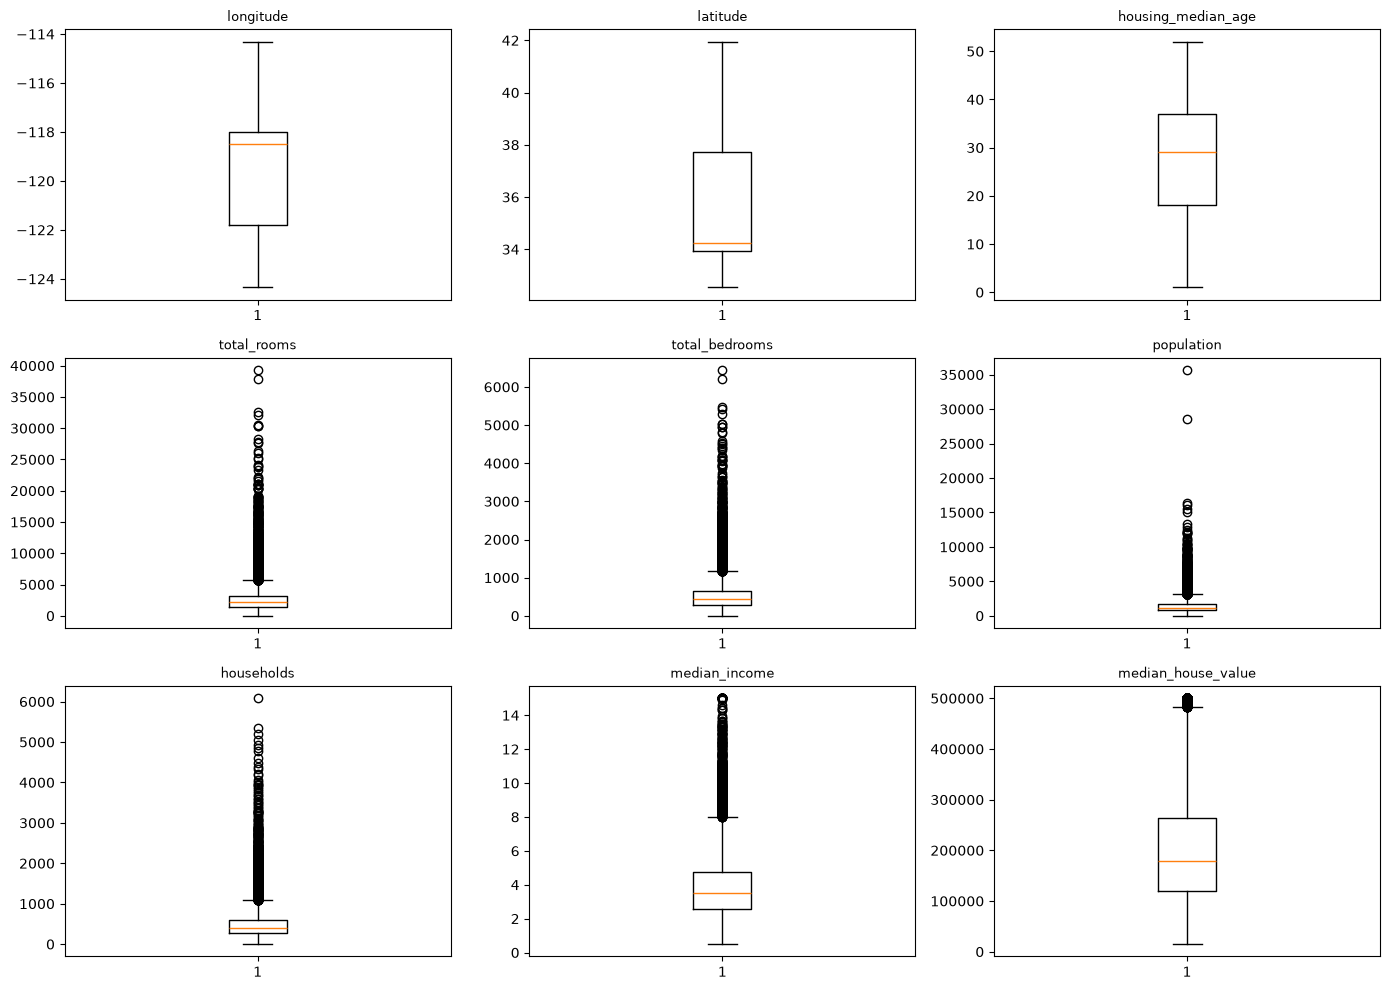

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

**Nulos:** de las 20,640 filas, a 207 les falta el dato de `total_bedrooms` (cuántos dormitorios tiene el distrito). Es menos del 1% del dataset, muy poco, así que no tiene sentido botar esas filas y perder información. En vez de eso se va a rellenar cada valor faltante con la mediana de esa columna (la mediana es el valor "de en medio" si ordenamos todos los distritos de menor a mayor cantidad de dormitorios; se prefiere sobre el promedio porque el promedio se distorsiona fácil cuando hay valores muy altos, y aquí sí los hay). Este relleno se va a hacer más adelante, después de dividir los datos en entrenamiento/validación/test, y calculando la mediana solo con los datos de entrenamiento. La razón es evitar lo que se conoce como data leakage (o "fuga de datos"): si calculo la mediana usando también los datos de validación o test, técnicamente le estaría dando al modelo información de esos conjuntos antes de tiempo, y eso hace que las métricas de evaluación luzcan mejores de lo que realmente serían con datos nuevos.

**Duplicados:** no hay ninguna fila repetida en el dataset, así que aquí no hubo nada que limpiar.

**Outliers:** un outlier es un dato que se sale mucho del comportamiento típico del resto. En los boxplots de arriba (esos gráficos de cajita que muestran dónde se concentra la mayoría de los datos y qué tan lejos quedan los valores extremos) se ve que columnas como `total_rooms`, `total_bedrooms`, `population`, `households` y `median_income` tienen bastantes puntos muy por encima del resto: son distritos con muchísimas más viviendas, personas o ingresos que el promedio. Esto tiene sentido porque California tiene zonas muy densas (ciudades grandes) y zonas muy dispersas (rurales), así que no son errores, son distritos reales que sí existen así.

Además encontré algo particular: `median_house_value` (el precio, mi target) nunca pasa de 500,001, y hay 965 distritos exactamente en ese número; y `housing_median_age` nunca pasa de 52, con 1,273 distritos justo en ese valor. Esto se llama truncamiento o "capping": quien armó el dataset originalmente le puso un techo a estas variables, entonces cualquier distrito que en la realidad tuviera un valor más alto quedó guardado con ese máximo. No es un error mío ni algo que pueda arreglar con los datos que tengo.

Decidí no eliminar ninguno de estos distritos "extremos", por dos razones: (1) son casos reales, no errores de digitación, y (2) si borrara el 5% de distritos con las viviendas más caras, el modelo aprendería viendo menos casos de precios altos y tendería a subestimar sistemáticamente el valor de las viviendas caras. En vez de borrar datos, la forma de manejar estos valores tan dispersos es escalando las variables numéricas (lo explico en la Pregunta 5), que es la práctica estándar para redes neuronales. Sí dejo anotado como limitación conocida: como el propio dataset le puso un techo al precio, el modelo nunca va a poder predecir con precisión distritos que en la vida real valen más de 500,001.

### Pregunta 4: ¿Qué variables son numéricas y cuáles categóricas? ¿Cómo codificó las categóricas?

In [6]:
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_feature_cols = [c for c in numeric_cols if c != 'median_house_value']

print('Variables numéricas (features):', numeric_feature_cols)
print('Variable categórica:', categorical_cols)
print()
print(df['ocean_proximity'].value_counts())

Variables numéricas (features): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Variable categórica: ['ocean_proximity']

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


De las 9 features, 8 son numéricas (`longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`) y 1 es categórica: `ocean_proximity`, que en vez de números tiene 5 etiquetas de texto (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`). Cabe resaltar que `ISLAND` es una categoría muy rara: solo 5 de los 20,640 distritos caen ahí.

Una red neuronal solo entiende números, así que hay que convertir `ocean_proximity` a algo numérico. La forma correcta de hacerlo aquí es con one-hot encoding, que consiste en crear una columna nueva por cada categoría posible, con un 1 en la columna que corresponde al distrito y 0 en las demás. Por ejemplo, un distrito `INLAND` quedaría como `INLAND=1, <1H OCEAN=0, NEAR OCEAN=0, NEAR BAY=0, ISLAND=0`.

¿Por qué no simplemente numerarlas (0, 1, 2, 3, 4)? Porque eso le haría creer a la red que hay un orden o una distancia entre las categorías (que "NEAR BAY" es "más" que "INLAND", por ejemplo), cuando en realidad son solo etiquetas distintas sin ningún orden entre sí (es una variable "nominal"). El one-hot evita ese problema, y como son solo 5 categorías, tampoco agrega demasiadas columnas nuevas.

Igual que con el relleno de nulos, esta codificación se va a definir usando solo los datos de entrenamiento y luego se aplicará igual a validación y test, para no mezclar información entre conjuntos.

### Pregunta 5: ¿Fue necesario normalizar o escalar las variables numéricas?

In [7]:
df[numeric_feature_cols].describe().loc[['min', 'max', 'mean', 'std']]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822


Sí, es necesario escalar. En la tabla de arriba se ve que cada variable numérica vive en un rango totalmente distinto: `latitude` y `longitude` se mueven entre 32 y 42, o entre -124 y -114; `median_income` va de 0.5 a 15; pero `total_rooms` o `population` llegan a decenas de miles. Es decir, están en "unidades" muy diferentes entre sí.

¿Por qué esto es un problema para la red neuronal? Una red aprende ajustando unos números internos (los "pesos") multiplicados por el valor de entrada de cada variable. Si una variable como `total_rooms` tiene valores miles de veces más grandes que `median_income`, al principio del entrenamiento esa variable va a producir señales mucho más grandes dentro de la red, simplemente por su tamaño, no porque sea más importante para predecir el precio. Esto hace que el entrenamiento avance de forma más lenta e inestable, ya que unas variables "opacan" a otras solo por su escala.

La solución estándar es **escalar** (o normalizar) las variables numéricas para que todas queden en un rango comparable. Voy a usar `StandardScaler`, que transforma cada variable para que tenga **media 0 y desviación estándar 1** (en otras palabras: le resta el promedio y luego la divide entre qué tanto varían sus datos). Así, todas las variables numéricas quedan en una escala parecida entre sí y ninguna domina el entrenamiento solo por tener números más grandes.

Igual que con el relleno de nulos y la codificación de categorías, el `scaler` se va a calcular usando solo los datos de entrenamiento (para saber cuál es su promedio y su variación) y luego esa misma transformación se aplica a validación y test, sin recalcular nada con esos datos.

### División en Train / Validation / Test

Voy a dividir el dataset en tres conjuntos, siguiendo la misma regla vista en clase:

- **Train (~70%):** el modelo aprende sus parámetros (pesos) directamente de estos datos.
- **Validation (~15%):** lo uso para ajustar hiperparámetros (arquitectura, learning rate, regularización, etc.) y decidir cuándo detener el entrenamiento.
- **Test (~15%):** lo uso una sola vez, al final, para medir el desempeño real del modelo sobre datos que nunca vio ni influyeron en ninguna decisión.

La regla de oro es que el conjunto de test nunca debe influir en decisiones de entrenamiento ni de ajuste de hiperparámetros, si lo hiciera, habría fuga de datos (data leakage) y la métrica final dejaría de reflejar el desempeño real del modelo con datos nuevos.

Para lograr esto con `train_test_split` (que solo divide en dos partes), lo aplico dos veces: primero separo el test del resto, y luego divido lo que queda en train y validation.

In [8]:
TEST_SIZE = 0.15
VAL_SIZE = 0.15

# Paso 1: separar test (15%) del resto (85%)
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Paso 2: del 85% restante, separar para validation.
# Como val es 15% del total, necesito que sea VAL_SIZE / (1 - TEST_SIZE) del subconjunto train_val
val_ratio_within_train_val = VAL_SIZE / (1 - TEST_SIZE)

train_df, val_df = train_test_split(
    train_val_df, test_size=val_ratio_within_train_val, random_state=RANDOM_STATE
)

print('Train:     ', train_df.shape, f'({len(train_df) / len(df):.1%})')
print('Validation:', val_df.shape, f'({len(val_df) / len(df):.1%})')
print('Test:      ', test_df.shape, f'({len(test_df) / len(df):.1%})')

Train:      (14448, 10) (70.0%)
Validation: (3096, 10) (15.0%)
Test:       (3096, 10) (15.0%)


Con esto quedo con **train ≈70%, validation ≈15% y test ≈15%** del total de distritos, tal como lo definí arriba. Uso `random_state=RANDOM_STATE` en ambos splits para que la división sea reproducible (si vuelvo a correr el notebook, obtengo exactamente los mismos tres conjuntos).

De aquí en adelante, cualquier decisión de preprocesamiento (rellenar nulos, codificar `ocean_proximity`, escalar) la voy a ajustar (`fit`) únicamente con `train_df`, y luego la aplico (`transform`) sobre `val_df` y `test_df`, respetando la regla de oro de no dejar que esos conjuntos influyan en ninguna decisión de entrenamiento.

### Preprocesamiento: imputar nulos, codificar y escalar

Ahora sí implemento lo que decidí en las Preguntas 3, 4 y 5, siempre ajustando (`fit`) cada transformación solo con `train_df` y aplicándola (`transform`) igual sobre `val_df` y `test_df`.

In [9]:
# 1) Separar features (X) y target (y) en cada conjunto
X_train_df = train_df[numeric_feature_cols + categorical_cols].copy()
X_val_df = val_df[numeric_feature_cols + categorical_cols].copy()
X_test_df = test_df[numeric_feature_cols + categorical_cols].copy()

y_train = train_df['median_house_value'].to_numpy(dtype=np.float32)
y_val = val_df['median_house_value'].to_numpy(dtype=np.float32)
y_test = test_df['median_house_value'].to_numpy(dtype=np.float32)

# 2) Nulos (mediana) en las columnas numéricas, ajustado solo con train
imputer = SimpleImputer(strategy='median')
X_train_df[numeric_feature_cols] = imputer.fit_transform(X_train_df[numeric_feature_cols])
X_val_df[numeric_feature_cols] = imputer.transform(X_val_df[numeric_feature_cols])
X_test_df[numeric_feature_cols] = imputer.transform(X_test_df[numeric_feature_cols])

print('Nulos en train después de imputar:', X_train_df[numeric_feature_cols].isnull().sum().sum())

Nulos en train después de imputar: 0


In [10]:
# 3) Codificar ocean_proximity con one-hot, ajustado solo con train
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_ohe = encoder.fit_transform(X_train_df[categorical_cols])
val_ohe = encoder.transform(X_val_df[categorical_cols])
test_ohe = encoder.transform(X_test_df[categorical_cols])

ohe_cols = encoder.get_feature_names_out(categorical_cols)
print('Columnas generadas por el one-hot:', list(ohe_cols))

Columnas generadas por el one-hot: ['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [11]:
# 4) Escalado las columnas numéricas, ajustado solo con train
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train_df[numeric_feature_cols])
val_scaled = scaler.transform(X_val_df[numeric_feature_cols])
test_scaled = scaler.transform(X_test_df[numeric_feature_cols])

# 5) Uno numéricas escaladas + categóricas one-hot en la matriz final de features
X_train = np.hstack([train_scaled, train_ohe]).astype(np.float32)
X_val = np.hstack([val_scaled, val_ohe]).astype(np.float32)
X_test = np.hstack([test_scaled, test_ohe]).astype(np.float32)

feature_names = numeric_feature_cols + list(ohe_cols)

print('X_train:', X_train.shape)
print('X_val:  ', X_val.shape)
print('X_test: ', X_test.shape)
print('Total de features de entrada al MLP:', X_train.shape[1])

X_train: (14448, 13)
X_val:   (3096, 13)
X_test:  (3096, 13)
Total de features de entrada al MLP: 13


Con esto termina la preparación de los datos: los 207 nulos de `total_bedrooms` quedaron rellenados con la mediana de `train_df`, `ocean_proximity` quedó convertida en 5 columnas one-hot, y las 8 variables numéricas quedaron escaladas (media 0, desviación 1) usando solo estadísticas de `train_df`. La matriz final de entrada al MLP (`X_train`, `X_val`, `X_test`) tiene 13 columnas (8 numéricas escaladas + 5 categorías de `ocean_proximity`), y `y_train`/`y_val`/`y_test` son el precio (`median_house_value`) sin transformar, que es lo que el modelo va a intentar predecir.

## 3. Investigación: optimizadores y capas de PyTorch para el MLP

En esta sección está investigación y explicación, sobre las piezas de `torch.nn` y `torch.optim` que voy a necesitar para armar el MLP de regresión: la capa lineal, las funciones de activación, dropout, batch normalization, las funciones de pérdida para regresión, y los optimizadores. Para cada una explico qué hace, cuáles son sus parámetros más importantes, y la pruebo con un ejemplo pequeño.

### 3.1 `nn.Linear`

Es la capa más básica de una red neuronal, porque es una capa totalmente conectada (fully connected / dense). Lo que hace por dentro es una operación matemática simple: `salida = entrada @ W^T + b`, es decir, multiplica cada entrada por una matriz de pesos `W` y le suma un vector de sesgo (bias) `b`. Esos pesos y ese bias son justo los números que la red va a ir ajustando durante el entrenamiento (son los "parámetros aprendibles").

Parámetros más importantes:
- **`in_features`**: cuántos números entran a la capa (el tamaño del vector de entrada). En mi caso, la primera capa del MLP va a tener `in_features=13`, porque así quedó mi `X_train` después del preprocesamiento.
- **`out_features`**: cuántos números salen de la capa. Esto es una decisión de diseño mía: si pongo `out_features=64`, esa capa va a tener 64 "neuronas".
- **`bias`** (default `True`): si la capa además de multiplicar por pesos le suma el vector `b`. Casi siempre se deja en `True`.

Cada `nn.Linear` transforma un vector de tamaño `in_features` en uno de tamaño `out_features`; apilando varias de estas capas (con activaciones en medio) es como se arma un MLP.

**Fuente:** [PyTorch Docs — torch.nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)

In [12]:
# Ejemplo pequeño: tomo un "lote" de 4 filas de X_train (4 distritos, 13 features cada uno)
sample_batch = torch.tensor(X_train[:4])
print('Entrada:', sample_batch.shape)  # (4, 13)

capa_demo = nn.Linear(in_features=13, out_features=5)
salida = capa_demo(sample_batch)

print('Salida: ', salida.shape)  # (4, 5)
print()
print('Forma de los pesos (W):', capa_demo.weight.shape)  # (out_features, in_features)
print('Forma del bias (b):   ', capa_demo.bias.shape)     # (out_features,)

Entrada: torch.Size([4, 13])
Salida:  torch.Size([4, 5])

Forma de los pesos (W): torch.Size([5, 13])
Forma del bias (b):    torch.Size([5])


### 3.2 Funciones de activación: `nn.ReLU`, `nn.LeakyReLU`, `nn.Tanh`

Si solo apilara capas `nn.Linear` una tras otra, toda la red seguiría siendo, matemáticamente, una única transformación lineal (una combinación de multiplicaciones y sumas), sin importar cuántas capas ponga. Eso limitaría mucho lo que la red puede aprender: no podría representar relaciones curvas o complejas entre las variables y el precio. Las **funciones de activación** son las que le agregan no-linealidad a la red: se aplican después de cada `nn.Linear` y "doblan" la señal antes de pasarla a la siguiente capa.

**`nn.ReLU`** (Rectified Linear Unit): aplica `ReLU(x) = max(0, x)`, es decir, deja pasar el valor tal cual si es positivo, y lo vuelve 0 si es negativo. Es la activación más usada por defecto en capas ocultas porque es barata de calcular y entrena rápido. Su parámetro principal es `inplace` (default `False`): si es `True`, modifica el tensor de entrada directamente en memoria en vez de crear uno nuevo (ahorra memoria, pero rara vez es necesario para un MLP de este tamaño). Su problema conocido es el de **"neuronas muertas"**: si una neurona empieza a dar siempre valores negativos, ReLU la deja siempre en 0 y su gradiente también es 0, entonces esa neurona deja de aprender.

**`nn.LeakyReLU`**: es una variante de ReLU pensada justo para el problema anterior. En vez de anular por completo los valores negativos, los deja pasar multiplicados por una pendiente pequeña: `LeakyReLU(x) = x si x ≥ 0`, y `LeakyReLU(x) = negative_slope * x si x < 0`. Su parámetro principal es `negative_slope` (default `0.01`), que controla qué tan "inclinada" es esa parte negativa. Al nunca dar exactamente 0 de gradiente, evita que las neuronas se "mueran" del todo.

**`nn.Tanh`** (tangente hiperbólica): aplica `Tanh(x) = (e^x - e^-x) / (e^x + e^-x)`, que "aplasta" cualquier valor de entrada a un rango entre **-1 y 1**. A diferencia de ReLU/LeakyReLU, es una curva suave (no tiene un quiebre en 0) y está centrada en 0, lo que a veces ayuda a que el entrenamiento sea más estable en redes pequeñas. Su desventaja es que para valores muy grandes o muy negativos la curva se "aplana" (se satura) y el gradiente se vuelve casi 0, lo que puede hacer el entrenamiento más lento en redes profundas. A diferencia de las otras dos, `nn.Tanh()` **no tiene parámetros de configuración relevantes**: se instancia sin argumentos (`nn.Tanh()`), porque la forma de la curva es siempre la misma, no depende de ningún valor que yo pueda ajustar.

**Fuentes:**
- [PyTorch Docs — torch.nn.ReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
- [PyTorch Docs — torch.nn.LeakyReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html)
- [PyTorch Docs — torch.nn.Tanh](https://docs.pytorch.org/docs/stable/generated/torch.nn.Tanh.html)

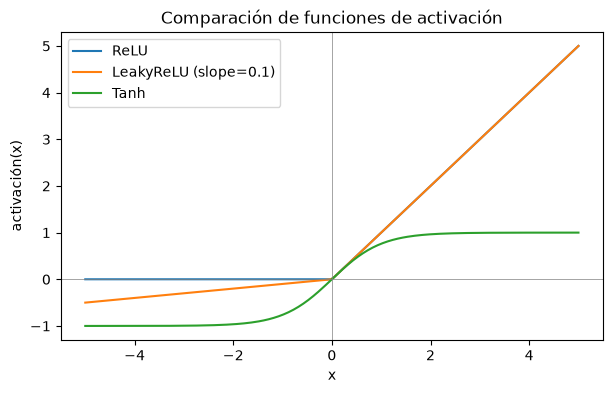

In [13]:
# Aplico las tres activaciones sobre el mismo rango de valores para ver cómo se comportan
x = torch.linspace(-5, 5, 200)

relu = nn.ReLU()
leaky_relu = nn.LeakyReLU(negative_slope=0.1)  # uso 0.1 (en vez del default 0.01) para que se note más en el gráfico
tanh = nn.Tanh()

plt.figure(figsize=(7, 4))
plt.plot(x, relu(x), label='ReLU')
plt.plot(x, leaky_relu(x), label='LeakyReLU (slope=0.1)')
plt.plot(x, tanh(x), label='Tanh')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.legend()
plt.title('Comparación de funciones de activación')
plt.xlabel('x')
plt.ylabel('activación(x)')
plt.show()

### 3.3 `nn.Dropout`

Es una técnica de **regularización**, es decir, una forma de evitar que el modelo se sobreajuste (overfitting) a los datos de entrenamiento. Durante el entrenamiento, en cada pasada hacia adelante, `nn.Dropout` apaga aleatoriamente (pone en 0) algunas neuronas de la capa a la que se aplica, con una probabilidad `p`. Esto obliga a la red a no depender demasiado de neuronas específicas, porque en cualquier momento esa neurona puede "desaparecer"; en la práctica, aprende representaciones más robustas y repartidas.

Parámetros más importantes:
- **`p`** (default `0.5`): la probabilidad de apagar cada neurona. Por ejemplo, `p=0.3` apaga en promedio un 30% de las neuronas de esa capa en cada pasada.
- **`inplace`** (default `False`): si modifica el tensor de entrada directamente en memoria en vez de crear uno nuevo.

Algo importante que investigué: dropout **solo actúa durante el entrenamiento**. Cuando el modelo está en modo evaluación (`model.eval()`), `nn.Dropout` se comporta como si no existiera (deja pasar todo tal cual), porque en ese momento quiero usar la red completa, no una versión recortada al azar. Además, mientras entrena, a las neuronas que sí sobreviven se les multiplica su valor por `1/(1-p)`, para que el promedio de la señal que llega a la siguiente capa se mantenga parecido con o sin dropout.

**Fuente:** [PyTorch Docs — torch.nn.Dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

In [14]:
# Demo: mismo tensor de entrada, en modo train vs modo eval
torch.manual_seed(RANDOM_STATE)
entrada_demo = torch.ones(1, 10)  # un vector de 10 unos, para ver claramente qué apaga y qué escala

dropout_demo = nn.Dropout(p=0.4)

dropout_demo.train()
print('Modo train (algunas se apagan, el resto se escala por 1/(1-p)):')
print(dropout_demo(entrada_demo))

dropout_demo.eval()
print('\nModo eval (no apaga nada, actúa como identidad):')
print(dropout_demo(entrada_demo))

Modo train (algunas se apagan, el resto se escala por 1/(1-p)):
tensor([[1.6667, 1.6667, 1.6667, 1.6667, 1.6667, 1.6667, 0.0000, 0.0000, 1.6667,
         1.6667]])

Modo eval (no apaga nada, actúa como identidad):
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


### 3.4 `nn.BatchNorm1d`

Es una capa que **normaliza las salidas de una capa oculta**, dentro de la propia red, no solo al principio (como hice con `StandardScaler` en los datos de entrada). Por cada mini-batch que pasa durante el entrenamiento, calcula la media y la varianza de cada neurona *en ese batch*, y usa esos valores para dejar la salida de esa neurona con media 0 y varianza 1; luego le aplica una pequeña transformación con dos parámetros aprendibles (`γ` y `β`) para que la red pueda, si le conviene, deshacer un poco esa normalización.

La idea de fondo (lo que se investigó como "internal covariate shift") es que, a medida que los pesos de las capas anteriores van cambiando durante el entrenamiento, la distribución de valores que recibe cada capa también va cambiando todo el tiempo, lo cual hace más lento e inestable el entrenamiento. `BatchNorm1d` estabiliza esa distribución capa por capa, lo que en la práctica suele permitir usar learning rates más altos y entrenar más rápido.

Parámetros más importantes:
- **`num_features`**: cuántas neuronas tiene la capa que estoy normalizando (debe coincidir con el `out_features` del `nn.Linear` anterior).
- **`eps`** (default `1e-5`): un número pequeño que se suma para evitar dividir entre 0 si la varianza del batch es casi 0.
- **`momentum`** (default `0.1`): qué tanto peso le da a cada nuevo batch al ir actualizando el promedio "global" de media/varianza que se usa después en evaluación.
- **`affine`** (default `True`): si aprende los parámetros `γ` (escala) y `β` (desplazamiento) mencionados arriba.

Igual que dropout, `BatchNorm1d` se comporta distinto en entrenamiento y evaluación: durante el entrenamiento usa la media/varianza del batch actual, pero durante evaluación (`model.eval()`) usa un promedio acumulado de esas estadísticas de todos los batches vistos en entrenamiento, para no depender del tamaño o composición de un batch de test.

**Fuente:** [PyTorch Docs — torch.nn.BatchNorm1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)

In [15]:
# Demo: aplico BatchNorm1d sobre un batch de 4 distritos, 5 features cada uno (salida de la demo de nn.Linear)
torch.manual_seed(RANDOM_STATE)
capa_demo2 = nn.Linear(in_features=13, out_features=5)
bn_demo = nn.BatchNorm1d(num_features=5)

salida_lineal = capa_demo2(sample_batch)
print('Media por feature ANTES de BatchNorm:', salida_lineal.mean(dim=0).detach().numpy().round(3))

bn_demo.train()
salida_bn = bn_demo(salida_lineal)
print('Media por feature DESPUÉS de BatchNorm (~0):', salida_bn.mean(dim=0).detach().numpy().round(3))
print('Varianza por feature DESPUÉS de BatchNorm (~1):', salida_bn.var(dim=0, unbiased=False).detach().numpy().round(3))

Media por feature ANTES de BatchNorm: [ 0.142 -0.034 -0.178 -0.229 -0.804]
Media por feature DESPUÉS de BatchNorm (~0): [-0.  0.  0.  0.  0.]
Varianza por feature DESPUÉS de BatchNorm (~1): [1.    0.999 0.999 1.    1.   ]


### 3.5 Funciones de pérdida para regresión: `nn.MSELoss`, `nn.L1Loss`, `nn.SmoothL1Loss`

La función de pérdida (loss) es lo que le dice a la red **qué tan mal** está prediciendo, comparando su salida contra el valor real (`median_house_value`). El entrenamiento consiste en ajustar los pesos para ir bajando ese número.

**`nn.MSELoss`** (Mean Squared Error / Error Cuadrático Medio): para cada distrito calcula `(predicción - valor_real)²`, y luego promedia (o suma, según el parámetro `reduction`) sobre todo el batch. Al elevar al cuadrado, los errores grandes pesan muchísimo más que los pequeños (un error de 100,000 pesa 100 veces más que uno de 10,000, no solo 10 veces más). Esto hace que el modelo se enfoque mucho en corregir los distritos donde más se equivoca, pero también lo vuelve **muy sensible a outliers**: unos pocos distritos con error enorme pueden dominar el entrenamiento.

**`nn.L1Loss`** (Mean Absolute Error / Error Absoluto Medio): para cada distrito calcula `|predicción - valor_real|` (valor absoluto, sin elevar al cuadrado) y promedia. Como no eleva al cuadrado, un error grande pesa proporcionalmente a su tamaño, no de forma explosiva. Es más robusto ante outliers que MSE, pero tiene una desventaja técnica: su gradiente es constante (no depende de qué tan grande es el error), lo que a veces hace el entrenamiento menos preciso cerca del mínimo.

**`nn.SmoothL1Loss`**: es un intermedio entre las dos anteriores. Para errores pequeños (menores al umbral `beta`) se comporta como MSE (cuadrática), y para errores grandes se comporta como L1 (lineal). Esto le da lo mejor de ambas: es sensible y da gradientes suaves para errores pequeños, pero no se deja dominar por outliers como sí le pasa a MSE. Su parámetro principal es `beta` (default `1.0`), el umbral que decide dónde cambia de comportamiento cuadrático a lineal.

Los tres comparten el parámetro `reduction` (`'mean'`, `'sum'` o `'none'`), que define cómo se combinan los errores de todo el batch en un solo número (por defecto, `'mean'`).

Dado que en mi dataset ya identifiqué outliers reales (Pregunta 3), `SmoothL1Loss` es un candidato interesante para probar además de `MSELoss`, precisamente porque es menos sensible a esos distritos extremos.

**Fuentes:**
- [PyTorch Docs — torch.nn.MSELoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)
- [PyTorch Docs — torch.nn.L1Loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)
- [PyTorch Docs — torch.nn.SmoothL1Loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.SmoothL1Loss.html)

In [16]:
# Demo: predicciones vs valores reales, con UN distrito muy mal predicho (outlier de error)
predicciones = torch.tensor([200_000.0, 250_000.0, 300_000.0, 900_000.0])  # el último está muy mal predicho
reales       = torch.tensor([210_000.0, 240_000.0, 310_000.0, 300_000.0])

mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()
smooth_l1_default = nn.SmoothL1Loss(beta=1.0)      # beta por defecto
smooth_l1_escalado = nn.SmoothL1Loss(beta=10_000.0)  # beta ajustado a la escala del precio (USD)

print(f'MSELoss:                    {mse_loss(predicciones, reales).item():,.2f}')
print(f'L1Loss:                     {l1_loss(predicciones, reales).item():,.2f}')
print(f'SmoothL1Loss (beta=1):      {smooth_l1_default(predicciones, reales).item():,.2f}')
print(f'SmoothL1Loss (beta=10,000): {smooth_l1_escalado(predicciones, reales).item():,.2f}')

MSELoss:                    90,074,996,736.00
L1Loss:                     157,500.00
SmoothL1Loss (beta=1):      157,499.50
SmoothL1Loss (beta=10,000): 152,500.00


Con este ejemplo (3 distritos bien predichos, error ~10,000, y 1 distrito muy mal predicho, error de 600,000) se nota justo el punto que investigué: `MSELoss` da un número enorme (billones) porque eleva al cuadrado un error ya de por sí grande en dólares, mientras que `L1Loss` se queda en la misma escala que el precio. También noto algo que no esperaba antes de probarlo: con el `beta` por defecto (`1.0`), `SmoothL1Loss` da prácticamente el mismo resultado que `L1Loss`, porque a la escala de dólares del precio (miles/cientos de miles), casi cualquier error ya es mayor a `1.0`, entonces siempre cae en la parte lineal de la fórmula. Para que la parte cuadrática de `SmoothL1Loss` realmente tenga efecto en este problema, hay que subir `beta` a algo del orden de la escala del error típico (por ejemplo, `10,000`), como se ve en la última fila.

### 3.6 Optimizadores: `torch.optim.SGD`, `torch.optim.Adam`, `torch.optim.RMSprop`

El optimizador es el que, usando el gradiente de la pérdida (calculado con `loss.backward()`, que propaga el error hacia atrás por todas las capas del MLP), decide **cómo actualizar cada peso** de la red en cada paso de entrenamiento. En un MLP, esto significa actualizar los pesos `W` y `b` de cada `nn.Linear` de la arquitectura, capa por capa. Todos los optimizadores comparten la idea básica de "moverse en la dirección que reduce la pérdida", pero difieren en qué tanta memoria usan de los pasos anteriores y en cómo ajustan el tamaño del paso para cada peso.

**El rol de `lr` (learning rate):** es el tamaño del paso que da el optimizador en cada actualización. Si `lr` es muy alto, los pesos pueden cambiar tan bruscamente que el entrenamiento se vuelve inestable o incluso diverge (la pérdida sube en vez de bajar). Si `lr` es muy bajo, el entrenamiento converge muy lento y puede quedarse atascado sin terminar de aprender dentro de los epochs disponibles. Es, en la práctica, uno de los hiperparámetros más importantes de ajustar.

**El rol de `weight_decay`:** es una forma de regularización L2. En cada paso, además de moverse según el gradiente de la pérdida, el optimizador "encoge" un poco todos los pesos hacia 0, proporcionalmente a `weight_decay`. Esto penaliza que los pesos crezcan demasiado grandes, lo que ayuda a evitar overfitting (una red con pesos muy grandes tiende a ajustarse demasiado a detalles específicos de los datos de entrenamiento).

---

**`SGD`** (Stochastic Gradient Descent): en el MLP, es el optimizador más simple: actualiza cada peso restándole `lr * gradiente`, sin ninguna memoria de los pasos anteriores. Investigué que en PyTorch también se le puede agregar `momentum` (default `0`), que acumula una especie de velocidad con los gradientes anteriores, para no cambiar de dirección tan brusco y avanzar más rápido en direcciones consistentes (algo parecido a una bola rodando que agarra impulso), también tiene `nesterov` (default `False`), una variante que mira un paso adelante antes de calcular el gradiente, y `dampening` (default `0`), que amortigua ese momentum. Sin momentum, SGD tiende a ser más lento y a zigzaguear en problemas donde la superficie de pérdida no es pareja en todas direcciones. Es el que menos memoria adicional necesita y el que menos asume sobre el problema, pero suele necesitar más epochs y un `lr` bien ajustado a mano.

**`Adam`** (Adaptive Moment Estimation): es el optimizador más usado hoy en día por default para entrenar MLPs. A diferencia de SGD, mantiene dos promedios móviles por cada peso: uno del gradiente (primer momento, controlado por `betas[0]`, default `0.9`) y otro del gradiente al cuadrado (segundo momento, controlado por `betas[1]`, default `0.999`). Con esos dos promedios, Adam le da a cada peso de cada capa del MLP su propio learning rate efectivo, a los pesos que han tenido gradientes grandes y consistentes les baja el paso (para no pasarse), y a los que han tenido gradientes pequeños les sube el paso (para que no se queden estancados). También tiene `eps` (default `1e-8`), un número pequeño que se suma al denominador para evitar dividir entre 0, y `amsgrad` (default `False`), una variante que en vez de usar el promedio móvil actual del segundo momento usa el máximo histórico, buscando una convergencia más estable. Esto lo hace converger rápido y ser bastante robusto incluso sin afinar mucho el `lr` a mano, por eso suele ser un buen punto de partida.

**`RMSprop`** (Root Mean Square Propagation): es, en cierta forma, un antecesor de Adam. También adapta el `lr` de cada peso del MLP, pero usando solo un promedio móvil del gradiente al cuadrado (controlado por `alpha`, default `0.99`), sin llevar memoria de la dirección del gradiente como sí hace Adam con su primer momento. El learning rate efectivo queda como `lr / sqrt(promedio_movil + eps)`, donde `eps` (default `1e-8`) evita divisiones entre 0. Al igual que SGD, también acepta un parámetro `momentum` (default `0`) para suavizar la trayectoria de actualización, y tiene la opción `centered` (default `False`), que además de la magnitud del gradiente considera una estimación de su varianza, buscando una normalización más precisa (a costa de más cómputo). Se usó originalmente mucho en redes recurrentes, y sigue siendo una alternativa razonable a Adam, aunque hoy Adam es más popular como default.

**En resumen, lo que más los diferencia:** SGD no adapta nada por sí solo (todos los pesos usan el mismo `lr`, salvo que le agregue momentum); RMSprop adapta el `lr` por peso usando solo la magnitud reciente del gradiente; y Adam hace lo mismo que RMSprop pero además usa memoria de la dirección del gradiente (momentum incorporado), combinando lo mejor de los dos. Por eso, para el MLP, decidí probar principalmente `Adam` (buen punto de partida por robusto) y comparar contra `SGD` (más simple, para ver si con más tuning de `lr`/momentum logra resultados parecidos) y `RMSprop` (para tener un tercer punto de comparación) en las iteraciones de la Sección 4.

**Fuentes:**
- [PyTorch Docs — torch.optim.SGD](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- [PyTorch Docs — torch.optim.Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)
- [PyTorch Docs — torch.optim.RMSprop](https://docs.pytorch.org/docs/stable/generated/torch.optim.RMSprop.html)

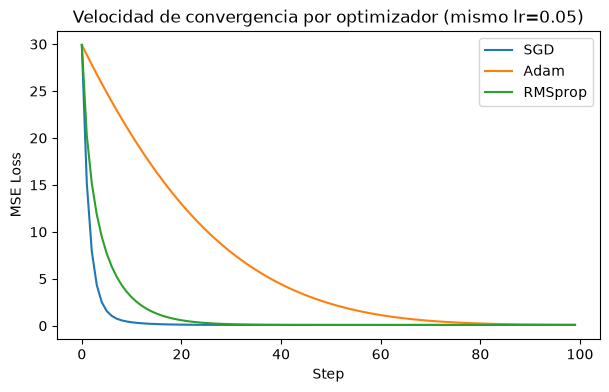

In [17]:
# Demo: comparo qué tan rápido baja la pérdida con cada optimizador, en un problema de juguete
# (regresión lineal simple: y = 3x + 2 + ruido), todos con el mismo lr y el mismo punto de partida

torch.manual_seed(RANDOM_STATE)
x_demo = torch.linspace(-3, 3, 100).unsqueeze(1)
y_demo = 3 * x_demo + 2 + 0.3 * torch.randn_like(x_demo)

def entrenar_con(optimizer_cls, **optimizer_kwargs):
    torch.manual_seed(0)  # mismo punto de partida (mismos pesos iniciales) para los tres
    modelo = nn.Linear(1, 1)
    optimizador = optimizer_cls(modelo.parameters(), **optimizer_kwargs)
    criterio = nn.MSELoss()

    historial = []
    for _ in range(100):
        optimizador.zero_grad()
        pred = modelo(x_demo)
        loss = criterio(pred, y_demo)
        loss.backward()
        optimizador.step()
        historial.append(loss.item())
    return historial

hist_sgd = entrenar_con(optim.SGD, lr=0.05)
hist_adam = entrenar_con(optim.Adam, lr=0.05)
hist_rmsprop = entrenar_con(optim.RMSprop, lr=0.05)

plt.figure(figsize=(7, 4))
plt.plot(hist_sgd, label='SGD')
plt.plot(hist_adam, label='Adam')
plt.plot(hist_rmsprop, label='RMSprop')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.title('Velocidad de convergencia por optimizador (mismo lr=0.05)')
plt.legend()
plt.show()

## 4. Entrenamiento e iteración de hiperparámetros

En esta sección definí una clase de MLP configurable, una función de entrenamiento reutilizable, y corrí 15 iteraciones usando Random Search que fue el tema visto en clase: en cada iteración se muestrea aleatoriamente todos los hiperparámetros a la vez (arquitectura, activación, optimizador/`lr`, batch size/epochs, y regularización) desde rangos y distribuciones que defino, en vez de cambiar una o dos variables a la vez desde un baseline fijo. Uso una semilla fija para que el muestreo sea reproducible.

### 4.1 Arquitectura del MLP

Definí una clase `MLP` que arma la red dinámicamente a partir de una lista de tamaños de capas ocultas (por ejemplo `[64, 32]` = dos capas ocultas, de 64 y 32 neuronas), usando lo que investigué en la Sección 3: `nn.Linear` para cada capa, la activación que le indique después de cada una, y opcionalmente `nn.BatchNorm1d` y `nn.Dropout`. La última capa es un `nn.Linear` sin activación, con una sola salida (el precio predicho), porque esto es regresión, no clasificación.

In [18]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, activation_cls=nn.ReLU,
                 dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        capas = []
        anterior = input_dim
        for tamano in hidden_sizes:
            capas.append(nn.Linear(anterior, tamano))
            if use_batchnorm:
                capas.append(nn.BatchNorm1d(tamano))
            capas.append(activation_cls())
            if dropout_p > 0:
                capas.append(nn.Dropout(dropout_p))
            anterior = tamano
        capas.append(nn.Linear(anterior, 1))  # capa de salida: 1 valor (el precio), sin activación
        self.red = nn.Sequential(*capas)

    def forward(self, x):
        return self.red(x).squeeze(1)  # (batch, 1) -> (batch,) para que coincida con la forma de y


# Prueba rápida: mismo lote de 4 distritos que usé en la Sección 3
modelo_prueba = MLP(input_dim=13, hidden_sizes=[64, 32], activation_cls=nn.ReLU, dropout_p=0.2)
print(modelo_prueba)
print()
print('Salida para 4 distritos:', modelo_prueba(sample_batch).shape)

MLP(
  (red): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Salida para 4 distritos: torch.Size([4])


### 4.2 Función de entrenamiento

Antes de escribir la función de entrenamiento, tuve que corregir algo y es que al primer intento de entrenar el baseline, el modelo divergía a `NaN` así que volví ejecutar el notebook para buscar el problema. La causa fue que nunca escalé el target (`median_house_value`), que llega hasta 500,001 dólares. Con `MSELoss` sobre esa escala, el error al cuadrado da números enormes (ya lo había visto en la Sección 3: ~90 mil millones en el ejemplo de la demo), y el gradiente inicial es tan grande que el entrenamiento se vuelve inestable desde los primeros pasos.

La solución es la misma idea que ya apliqué a las features en la Sección 2: escalar `y` con `StandardScaler`, ajustado solo con `y_train`, y aplicado igual a `y_val`/`y_test`. Entrené y medí las curvas de pérdida en esta escala normalizada (números pequeños, mucho más estables numéricamente), y solo al final, para reportar MSE/MAE/RMSE en dólares (que es lo que realmente quiero comunicar), "desescalo" las predicciones con `inverse_transform` antes de compararlas contra el precio real.

Ahora sí, la función `train_model` recibe el modelo, el optimizador, la función de pérdida, y hace el ciclo estándar de PyTorch en cada epoch: para cada batch, `zero_grad()` → `forward` → calcular `loss` → `backward()` → `optimizer.step()`. Al final de cada epoch, mido también la pérdida sobre `X_val`/`y_val` completos (con `model.eval()` y `torch.no_grad()`, para que dropout/batchnorm se comporten en modo evaluación y no gaste memoria en gradientes que no voy a usar), y guardo ambas pérdidas para poder graficar las curvas después.

También le agregué soporte opcional para regularización L1 este a diferencia de L2 (`weight_decay`), que ya viene integrado en los optimizadores de PyTorch, L1 no tiene un parámetro directo, así que lo implemento a mano sumándole a la pérdida `l1_lambda * suma(|peso|)` de todos los pesos del modelo antes de hacer `backward()`.

In [19]:
# Escalo el target (y) igual que las features: ajustado solo con y_train
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).astype(np.float32).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).astype(np.float32).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).astype(np.float32).ravel()

# Tensores de entrenamiento/validación/test (no cambian entre iteraciones, los dejo listos una sola vez)
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train_scaled)  # escalado: se usa para entrenar y para las curvas de pérdida
X_val_t = torch.tensor(X_val)
y_val_t = torch.tensor(y_val_scaled)      # escalado: idem
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test_scaled)    # escalado: idem


def train_model(model, optimizer, loss_fn, batch_size, epochs, l1_lambda=0.0):
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    historial = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if l1_lambda > 0:
                # Regularización L1: penalizo la suma de valores absolutos de todos los pesos
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm
            loss.backward()
            optimizer.step()

        # Al final de cada epoch, mido pérdida (en escala normalizada) en train completo y en validation completo
        model.eval()
        with torch.no_grad():
            train_loss_epoch = loss_fn(model(X_train_t), y_train_t).item()
            val_loss_epoch = loss_fn(model(X_val_t), y_val_t).item()
        historial['train_loss'].append(train_loss_epoch)
        historial['val_loss'].append(val_loss_epoch)

    return historial


def evaluar_en(modelo, X_t, y_original_np):
    # Predice en escala normalizada y "desescala" antes de comparar contra el precio real en dólares
    modelo.eval()
    with torch.no_grad():
        pred_scaled = modelo(X_t).numpy().reshape(-1, 1)
    pred_dollars = y_scaler.inverse_transform(pred_scaled).ravel()

    mse = mean_squared_error(y_original_np, pred_dollars)
    mae = mean_absolute_error(y_original_np, pred_dollars)
    rmse = root_mean_squared_error(y_original_np, pred_dollars)
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse}

### 4.3 Diseño del experimento: Random Search

En clase vimos la diferencia entre **Grid Search** (probar TODAS las combinaciones de una malla de valores definida manualmente para cada hiperparámetro) y **Random Search** (muestrear combinaciones al azar dentro de rangos o distribuciones definidas para cada hiperparámetro, todos a la vez). Elegí **Random Search** por la razón que vimos en la diapositiva: tengo 7 hiperparámetros que quiero explorar (número de capas, neuronas por capa, activación, optimizador, `lr`, batch size, epochs, y regularización), un grid search completo crecería exponencialmente (con solo 3 valores por hiperparámetro ya serían 3^7 ≈ 2,187 combinaciones), mientras que random search suele encontrar buenas combinaciones muestreando muchas menos evaluaciones.

Aquí defino el espacio de búsqueda (rangos/distribuciones) para cada hiperparámetro:

| Hiperparámetro | Espacio de búsqueda |
|---|---|
| Número de capas ocultas | Elección uniforme entre {1, 2, 3} |
| Neuronas por capa | Elección uniforme entre {16, 32, 64, 128, 256} (una elección independiente por cada capa) |
| Activación | Elección uniforme entre {ReLU, LeakyReLU, Tanh} |
| Optimizador | Elección uniforme entre {Adam, SGD, RMSprop} |
| `lr` | Log-uniforme entre 1e-4 y 5e-2 |
| Batch size | Elección uniforme entre {16, 32, 64, 128, 256} |
| Epochs | Elección uniforme entre {30, 50, 80} |
| Regularización | Elección uniforme entre {ninguna, dropout, L2, L1, dropout+L2} |
| `dropout_p` (si la regularización la incluye) | Uniforme entre 0.1 y 0.5 |
| `weight_decay` (si la regularización la incluye) | Log-uniforme entre 1e-5 y 1e-2 |
| `l1_lambda` (si la regularización la incluye) | Log-uniforme entre 1e-6 y 1e-3 |

Usé una distribución log-uniforme para `lr`, `weight_decay` y `l1_lambda` (en vez de uniforme normal) porque estos hiperparámetros afectan el entrenamiento en escalas multiplicativas, no aditivas: la diferencia entre `lr=0.0001` y `lr=0.001` es tan importante como la diferencia entre `lr=0.001` y `lr=0.01` (ambas son "multiplicar por 10"), así que muestrear en escala logarítmica cubre el rango de forma más pareja que un muestreo uniforme normal.

In [20]:
def get_optimizer(name, params, lr, weight_decay=0.0, momentum=0.0):
    if name == 'Adam':
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == 'SGD':
        return optim.SGD(params, lr=lr, weight_decay=weight_decay, momentum=momentum)
    elif name == 'RMSprop':
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=momentum)
    else:
        raise ValueError(f'Optimizador no soportado: {name}')


espacio_busqueda = {
    'n_capas': [1, 2, 3],
    'neuronas_por_capa': [16, 32, 64, 128, 256],
    'activaciones': [nn.ReLU, nn.LeakyReLU, nn.Tanh],
    'optimizadores': ['Adam', 'SGD', 'RMSprop'],
    'lr_rango_log': (1e-4, 5e-2),
    'batch_sizes': [16, 32, 64, 128, 256],
    'epochs_opciones': [30, 50, 80],
    'regularizaciones': ['ninguna', 'dropout', 'l2', 'l1', 'dropout+l2'],
    'dropout_rango': (0.1, 0.5),
    'weight_decay_rango_log': (1e-5, 1e-2),
    'l1_lambda_rango_log': (1e-6, 1e-3),
}


def muestrear_log_uniforme(rng, minimo, maximo):
    log_min, log_max = math.log10(minimo), math.log10(maximo)
    return 10 ** rng.uniform(log_min, log_max)


def muestrear_config(rng, idx):
    n_capas = rng.choice(espacio_busqueda['n_capas'])
    hidden_sizes = [rng.choice(espacio_busqueda['neuronas_por_capa']) for _ in range(n_capas)]
    activation_cls = rng.choice(espacio_busqueda['activaciones'])
    optimizer_name = rng.choice(espacio_busqueda['optimizadores'])
    lr = muestrear_log_uniforme(rng, *espacio_busqueda['lr_rango_log'])
    batch_size = rng.choice(espacio_busqueda['batch_sizes'])
    epochs = rng.choice(espacio_busqueda['epochs_opciones'])
    momentum = rng.uniform(0.5, 0.95) if optimizer_name in ('SGD', 'RMSprop') else 0.0

    regularizacion = rng.choice(espacio_busqueda['regularizaciones'])
    dropout_p = rng.uniform(*espacio_busqueda['dropout_rango']) if 'dropout' in regularizacion else 0.0
    weight_decay = muestrear_log_uniforme(rng, *espacio_busqueda['weight_decay_rango_log']) if 'l2' in regularizacion else 0.0
    l1_lambda = muestrear_log_uniforme(rng, *espacio_busqueda['l1_lambda_rango_log']) if 'l1' in regularizacion else 0.0

    return dict(
        nombre=f'Random {idx}',
        grupo='random',
        hidden_sizes=hidden_sizes,
        activation_cls=activation_cls,
        optimizer_name=optimizer_name,
        lr=lr,
        batch_size=batch_size,
        epochs=epochs,
        momentum=momentum,
        dropout_p=dropout_p,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        regularizacion=regularizacion,
    )


rng = random.Random(RANDOM_STATE)  # generador propio, independiente, para que el muestreo sea reproducible
N_ITERACIONES = 15
configuraciones = [muestrear_config(rng, i + 1) for i in range(N_ITERACIONES)]

df_config_preview = pd.DataFrame(configuraciones)[
    ['nombre', 'hidden_sizes', 'activation_cls', 'optimizer_name', 'lr',
     'batch_size', 'epochs', 'regularizacion', 'dropout_p', 'weight_decay', 'l1_lambda']
].copy()
df_config_preview['activation_cls'] = df_config_preview['activation_cls'].apply(lambda c: c.__name__)
df_config_preview['lr'] = df_config_preview['lr'].round(5)
df_config_preview['dropout_p'] = df_config_preview['dropout_p'].round(3)
df_config_preview['weight_decay'] = df_config_preview['weight_decay'].round(6)
df_config_preview['l1_lambda'] = df_config_preview['l1_lambda'].round(7)
df_config_preview

,nombre,hidden_sizes,activation_cls,optimizer_name,lr,batch_size,epochs,regularizacion,dropout_p,weight_decay,l1_lambda
0,Random 1,"[16, 16, 64]",ReLU,Adam,0.00024,16,80,dropout+l2,0.135,0.000184,0.000000
1,Random 2,[16],ReLU,Adam,0.00231,16,80,dropout,0.386,0.000000,0.000000
2,Random 3,"[256, 128, 32]",LeakyReLU,RMSprop,0.00056,16,30,l2,0.000,0.000068,0.000000
3,Random 4,[64],ReLU,Adam,0.00106,64,50,dropout+l2,0.206,0.000014,0.000000
4,Random 5,"[256, 16]",LeakyReLU,Adam,0.00309,256,50,dropout+l2,0.177,0.000016,0.000000
5,Random 6,"[32, 64, 16]",ReLU,Adam,0.00106,128,80,l2,0.000,0.000031,0.000000
6,Random 7,"[32, 64]",Tanh,RMSprop,0.00561,256,80,dropout,0.165,0.000000,0.000000
7,Random 8,"[64, 256]",ReLU,RMSprop,0.00075,16,30,l2,0.000,0.000160,0.000000
8,Random 9,[32],Tanh,RMSprop,0.00071,128,50,l1,0.000,0.000000,0.000003
9,Random 10,[32],Tanh,RMSprop,0.00285,256,50,l1,0.000,0.000000,0.000012


### 4.4 Corriendo las 15 configuraciones

Para cada configuración muestreada: creé el modelo y el optimizador desde cero (para que ninguna iteración arranque con pesos ya entrenados de la anterior), entreno con `train_model`, y evalúo el modelo entrenado sobre `X_val`/`y_val` con MSE, MAE y RMSE. Al final guardo todo (configuración + historial de pérdidas + métricas + el modelo entrenado) en la lista `resultados`, que reutilizo en la Sección 5 para la tabla resumen.

In [21]:
resultados = []

for cfg in configuraciones:
    torch.manual_seed(RANDOM_STATE)  # mismo punto de partida para todas, para que la comparación sea justa

    modelo = MLP(input_dim=X_train.shape[1], hidden_sizes=cfg['hidden_sizes'],
                 activation_cls=cfg['activation_cls'], dropout_p=cfg['dropout_p'])
    optimizador = get_optimizer(cfg['optimizer_name'], modelo.parameters(),
                                 cfg['lr'], cfg['weight_decay'], cfg['momentum'])

    historial = train_model(modelo, optimizador, nn.MSELoss(),
                             cfg['batch_size'], cfg['epochs'], l1_lambda=cfg['l1_lambda'])
    metricas_val = evaluar_en(modelo, X_val_t, y_val)  # y_val: target original en dólares

    resultados.append({
        **cfg,
        'activation_name': cfg['activation_cls'].__name__,
        'modelo': modelo,
        'historial': historial,
        'val_MSE': metricas_val['MSE'],
        'val_MAE': metricas_val['MAE'],
        'val_RMSE': metricas_val['RMSE'],
    })

    print(f"{cfg['nombre']:45s} val_RMSE={metricas_val['RMSE']:>10,.0f}  val_MAE={metricas_val['MAE']:>10,.0f}")

Random 1                                      val_RMSE=    56,044  val_MAE=    40,725


Random 2                                      val_RMSE=    61,246  val_MAE=    43,495


Random 3                                      val_RMSE=    54,788  val_MAE=    37,282


Random 4                                      val_RMSE=    56,020  val_MAE=    38,974


Random 5                                      val_RMSE=    51,791  val_MAE=    34,927


...

Random 11                                     val_RMSE=    72,192  val_MAE=    49,403


Random 12                                     val_RMSE=    60,684  val_MAE=    43,787


Random 13                                     val_RMSE=    67,760  val_MAE=    49,480


Random 14                                     val_RMSE=    54,193  val_MAE=    37,416


Random 15                                     val_RMSE=    71,777  val_MAE=    52,702


### 4.6 Curvas de pérdida (train vs. validation)

Grafiqué las curvas de al menos 3 iteraciones, elegidas dinámicamente según su desempeño en validación: la mejor (menor `val_RMSE`), la peor (mayor `val_RMSE`), y una intermedia (la de la mediana), para poder comparar visualmente cómo entrenan configuraciones buenas vs. malas y detectar señales de overfitting o underfitting. Las curvas están en la escala normalizada de `y` (no en dólares), que es en la que efectivamente se entrena el modelo.

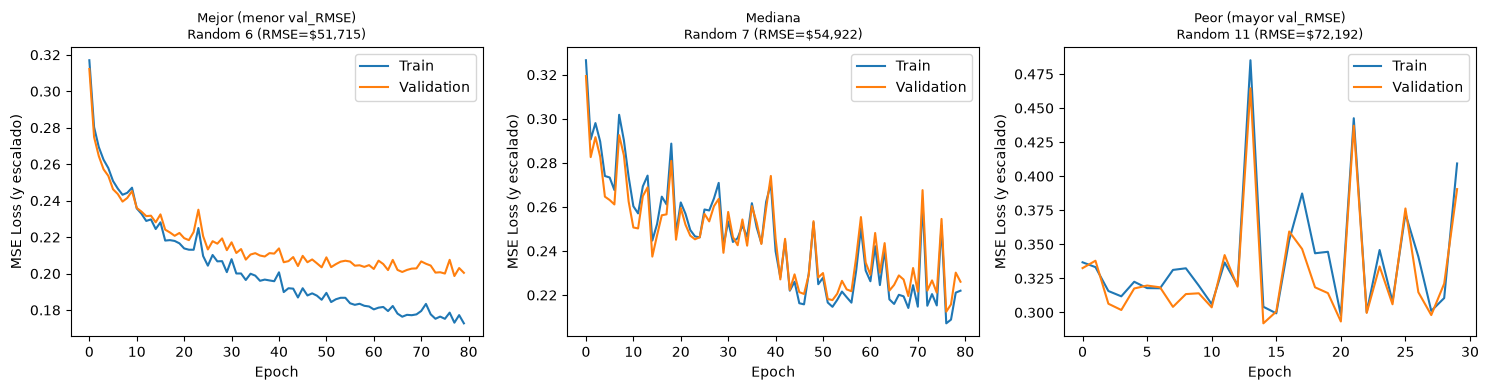

In [22]:
df_todo = pd.DataFrame(resultados)
df_ordenado = df_todo.sort_values('val_RMSE').reset_index(drop=True)

idx_mejor = 0
idx_peor = len(df_ordenado) - 1
idx_mediana = len(df_ordenado) // 2

seleccion = df_ordenado.iloc[[idx_mejor, idx_mediana, idx_peor]]
etiquetas = ['Mejor (menor val_RMSE)', 'Mediana', 'Peor (mayor val_RMSE)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, fila), etiqueta in zip(axes, seleccion.iterrows(), etiquetas):
    hist = fila['historial']
    ax.plot(hist['train_loss'], label='Train')
    ax.plot(hist['val_loss'], label='Validation')
    ax.set_title(f"{etiqueta}\n{fila['nombre']} (RMSE=${fila['val_RMSE']:,.0f})", fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss (y escalado)')
    ax.legend()
plt.tight_layout()
plt.show()

### 4.7 Mejor configuración y evaluación final sobre test

La mejor de las 13 configuraciones según su `val_RMSE` (la métrica de validación), y solo con esa realicé la evaluación final sobre el conjunto de test. Esto lo hago una única vez como indica la regla de oro.

In [23]:
df_todo_sorted = df_todo.sort_values('val_RMSE').reset_index(drop=True)
print(f'Ranking de las {len(df_todo_sorted)} configuraciones (Random Search) por val_RMSE:')
print(df_todo_sorted[['nombre', 'val_MSE', 'val_MAE', 'val_RMSE']].to_string(index=False))

mejor_fila = df_todo_sorted.iloc[0]
mejor_modelo = mejor_fila['modelo']
print()
print(f"Mejor configuración según validación: {mejor_fila['nombre']}")

metricas_test = evaluar_en(mejor_modelo, X_test_t, y_test)
print()
print('Métricas del modelo final sobre TEST (evaluado una única vez):')
print(f"MSE:  {metricas_test['MSE']:,.2f}")
print(f"MAE:  {metricas_test['MAE']:,.2f}")
print(f"RMSE: {metricas_test['RMSE']:,.2f}")

Ranking de las 15 configuraciones (Random Search) por val_RMSE:
   nombre      val_MSE      val_MAE     val_RMSE
 Random 6 2674404864.0 34209.125000 51714.648438
 Random 5 2682349824.0 34926.972656 51791.406250
Random 10 2914690304.0 36992.746094 53987.871094
 Random 9 2925590784.0 37569.996094 54088.730469
Random 14 2936841472.0 37416.234375 54192.632812
 Random 8 2957308160.0 37411.578125 54381.136719
 Random 3 3001732352.0 37282.027344 54788.066406
 Random 7 3016455680.0 37226.750000 54922.269531
 Random 4 3138283776.0 38973.726562 56020.386719
 Random 1 3140968704.0 40725.136719 56044.347656
Random 12 3682599680.0 43787.027344 60684.425781
 Random 2 3751065344.0 43495.089844 61245.941406
Random 13 4591471616.0 49479.925781 67760.398438
Random 15 5152005632.0 52702.160156 71777.476562
Random 11 5211655168.0 49403.285156 72191.796875

Mejor configuración según validación: Random 6

Métricas del modelo final sobre TEST (evaluado una única vez):
MSE:  2,888,969,728.00
MAE:  35,905.43
R

## 5. Documentación de resultados

Construyo la tabla resumen de las 15 iteraciones, con el mismo formato sugerido en el enunciado (arquitectura, activación, optimizador/LR, batch/epochs, regularización, y las 3 métricas de validación), ordenada de mejor a peor según `RMSE (val)`.

In [24]:
def formatear_regularizacion(fila):
    partes = []
    if fila['dropout_p'] > 0:
        partes.append(f"Dropout p={fila['dropout_p']:.2f}")
    if fila['weight_decay'] > 0:
        partes.append(f"L2={fila['weight_decay']:.2e}")
    if fila['l1_lambda'] > 0:
        partes.append(f"L1={fila['l1_lambda']:.2e}")
    return ' + '.join(partes) if partes else 'Ninguna'


def formatear_optimizador(fila):
    texto = f"{fila['optimizer_name']} / lr={fila['lr']:.4f}"
    if fila['optimizer_name'] in ('SGD', 'RMSprop'):
        texto += f", momentum={fila['momentum']:.2f}"
    return texto


tabla_resumen = pd.DataFrame({
    'Configuración': df_todo['nombre'],
    'Arquitectura': df_todo['hidden_sizes'].apply(str),
    'Activación': df_todo['activation_name'],
    'Optimizador / LR': df_todo.apply(formatear_optimizador, axis=1),
    'Batch / Epochs': df_todo.apply(lambda f: f"{f['batch_size']} / {f['epochs']}", axis=1),
    'Regularización': df_todo.apply(formatear_regularizacion, axis=1),
    'MSE (val)': df_todo['val_MSE'].round(0),
    'MAE (val)': df_todo['val_MAE'].round(0),
    'RMSE (val)': df_todo['val_RMSE'].round(0),
})

tabla_resumen = tabla_resumen.sort_values('RMSE (val)').reset_index(drop=True)
tabla_resumen.index = tabla_resumen.index + 1
tabla_resumen.index.name = '#'
tabla_resumen

,Configuración,Arquitectura,Activación,Optimizador / LR,Batch / Epochs,Regularización,MSE (val),MAE (val),RMSE (val)
#,,,,,,,,,
1,Random 6,"[32, 64, 16]",ReLU,Adam / lr=0.0011,128 / 80,L2=3.08e-05,2.674405e+09,34209.0,51715.0
2,Random 5,"[256, 16]",LeakyReLU,Adam / lr=0.0031,256 / 50,Dropout p=0.18 + L2=1.62e-05,2.682350e+09,34927.0,51791.0
3,Random 10,[32],Tanh,"RMSprop / lr=0.0028, momentum=0.90",256 / 50,L1=1.22e-05,2.914690e+09,36993.0,53988.0
4,Random 9,[32],Tanh,"RMSprop / lr=0.0007, momentum=0.90",128 / 50,L1=2.68e-06,2.925591e+09,37570.0,54089.0
5,Random 14,[256],ReLU,"RMSprop / lr=0.0006, momentum=0.59",256 / 80,L2=1.94e-03,2.936841e+09,37416.0,54193.0
6,Random 8,"[64, 256]",ReLU,"RMSprop / lr=0.0008, momentum=0.87",16 / 30,L2=1.60e-04,2.957308e+09,37412.0,54381.0
7,Random 3,"[256, 128, 32]",LeakyReLU,"RMSprop / lr=0.0006, momentum=0.81",16 / 30,L2=6.82e-05,3.001732e+09,37282.0,54788.0
8,Random 7,"[32, 64]",Tanh,"RMSprop / lr=0.0056, momentum=0.58",256 / 80,Dropout p=0.17,3.016456e+09,37227.0,54922.0
9,Random 4,[64],ReLU,Adam / lr=0.0011,64 / 50,Dropout p=0.21 + L2=1.35e-05,3.138284e+09,38974.0,56020.0
